<a href="https://colab.research.google.com/github/datacentertugaskuliah-coder/PraktekJST/blob/main/IMPLEMENTASI_ROC_MULTICLASS_YANG_ROBUST_UNTUK_PREDIKSI_DROPOUT_MAHASISWA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Implementasi ROC Multiclass yang Robust dengan Perbaikan Otomatis

Program dimulai. Silakan pilih cara input dataset.

PILIH METODE INPUT DATASET
1 = Path file lokal
2 = Upload file dari komputer
3 = URL CSV mentah/raw
Masukkan pilihan (1/2/3): 2


Saving students_dropout_academic_success.csv to students_dropout_academic_success (3).csv

INFORMASI DATASET
- Ukuran dataset      : (4424, 37)
- Kolom target        : Target
- Dasar deteksi target: terdeteksi otomatis berdasarkan nama kolom

DISTRIBUSI KELAS
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


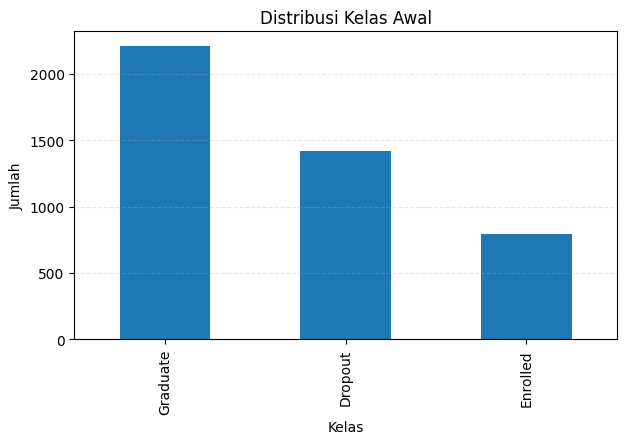


RINGKASAN FITUR
- Jumlah fitur numerik    : 36
- Jumlah fitur kategorikal: 0

TIGA REKOMENDASI PERBAIKAN
1. Rekomendasi 1 — Pertahankan validasi input dan deteksi skema data secara ketat. Perbaikan ini sudah diterapkan melalui pembacaan CSV robust, deteksi target, dan koersi ringan untuk kolom numerik tersimpan sebagai teks.
2. Rekomendasi 2 — Terapkan resampling hanya pada data latih karena distribusi kelas cukup timpang (rasio mayoritas:minoritas ≈ 2.78). Perbaikan otomatis akan memakai SMOTE jika aman; bila tidak aman, fallback ke RandomOverSampler.
3. Rekomendasi 3 — Baseline relatif stabil, tetapi model revisi tetap dibangun untuk menguji apakah penanganan imbalance dan model non-linear meningkatkan kualitas prediksi.

MODEL AKHIR
- Model terpilih : Baseline_LogisticRegression_Balanced
- Alasan         : Baseline dipertahankan demi integritas karena revisi tidak memberi keuntungan yang cukup.

TABEL PERBANDINGAN MODEL


,Model,CV_F1_Macro_Mean,Train_F1_Macro,Test_F1_Macro,Accuracy_Test,AUC_Macro,AUC_Weighted,Gap_Train_Test
0,Baseline_LogisticRegression_Balanced,0.7036,0.7201,0.6927,0.7288,0.8767,0.8956,0.0274
1,Improved_RandomForest_SMOTE(k_neighbors=5),0.7140,0.8696,0.6960,0.7446,0.8873,0.9040,0.1736


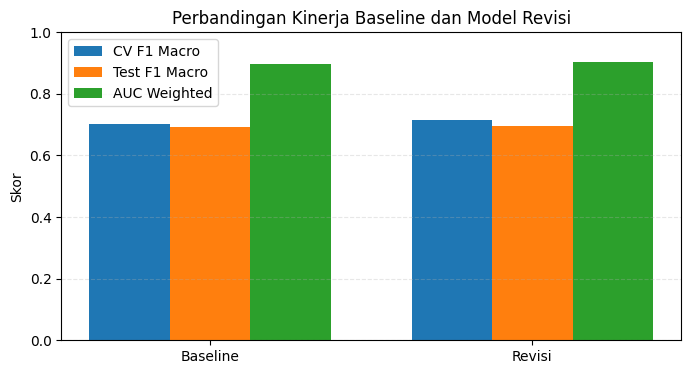


CLASSIFICATION REPORT — MODEL AKHIR
              precision    recall  f1-score   support

     Dropout       0.85      0.68      0.76       284
    Enrolled       0.41      0.64      0.50       159
    Graduate       0.86      0.79      0.82       442

    accuracy                           0.73       885
   macro avg       0.70      0.70      0.69       885
weighted avg       0.77      0.73      0.74       885



<Figure size 600x500 with 0 Axes>

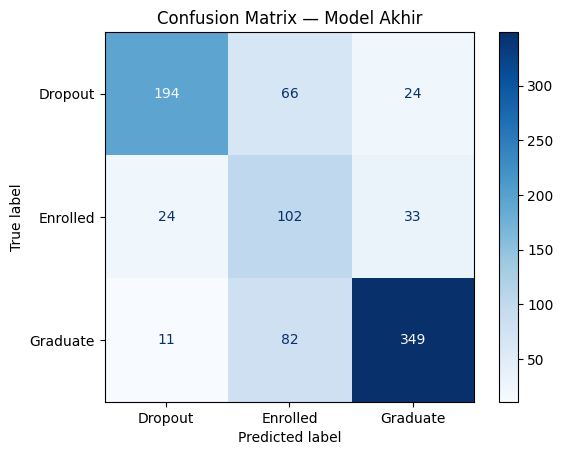

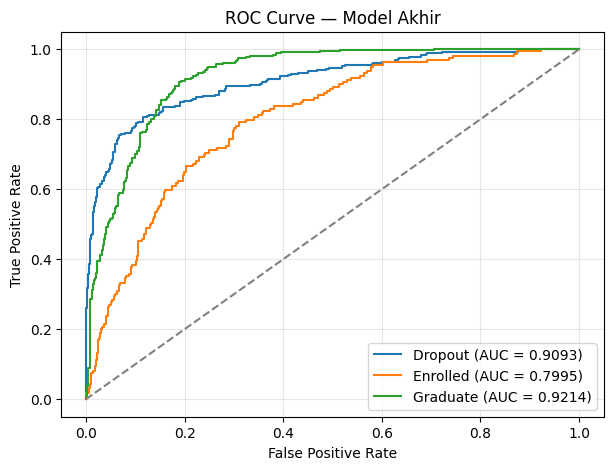


RINGKASAN AUC MODEL AKHIR
- AUC Macro    : 0.8767
- AUC Weighted : 0.8956

UJI SEDERHANA (SANITY CHECK) — 5 DATA PERTAMA DARI TEST SET


,Index_Data,Aktual,Prediksi
0,1853,Graduate,Graduate
1,2399,Graduate,Graduate
2,510,Enrolled,Dropout
3,242,Graduate,Graduate
4,3392,Graduate,Graduate



Model akhir berhasil disimpan sebagai: model_akhir_dropout_robust.pkl

KESIMPULAN
- Keseimbangan train-test relatif baik; tidak tampak gejala overfitting/underfitting yang berat.
- Kemampuan diskriminasi model tergolong baik menurut AUC weighted.
- Gunakan hasil test set ini sebagai evaluasi praktis. Untuk penelitian yang lebih ketat,
  pertimbangkan nested cross-validation atau holdout eksternal.


In [6]:
# =========================================================
# JUDUL PROGRAM
# IMPLEMENTASI ROC MULTICLASS YANG ROBUST UNTUK PREDIKSI DROPOUT MAHASISWA
# =========================================================

"""
DESKRIPSI SINGKAT
Program ini dirancang untuk membangun model klasifikasi status mahasiswa
(Dropout, Enrolled, Graduate) secara logis, robust, dan mudah dipahami.

Fokus utama program:
1. Mencegah error pembacaan dataset.
2. Mencegah logika kritikal yang salah pada preprocessing dan evaluasi.
3. Memberikan 3 rekomendasi perbaikan secara otomatis berdasarkan diagnosis awal.
4. Melakukan revisi model secara otomatis berdasarkan rekomendasi tersebut.
5. Mengevaluasi model dengan ROC, AUC, confusion matrix, tabel ringkasan, dan uji sederhana.

Catatan metodologis:
- Program mendukung 3 cara input data: path lokal, upload file, atau URL CSV mentah/raw.
- Untuk URL, gunakan URL file CSV mentah/raw, bukan halaman deskripsi dataset.
- Program tetap dapat berjalan untuk data biner atau multiclass, tetapi ROC multiclass
  akan dievaluasi dengan pendekatan One-vs-Rest.
"""

# =========================================================
# 1. INSTALASI DAN IMPORT PUSTAKA
# =========================================================
!pip -q install imbalanced-learn joblib

import warnings, re, os, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score, f1_score, accuracy_score
)

from imblearn.over_sampling import SMOTE, RandomOverSampler

# =========================================================
# 2. UTILITAS ROBUST UNTUK MENCEGAH ERROR
# =========================================================
def buat_onehot_encoder():
    """Kompatibel untuk beberapa versi scikit-learn."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def baca_csv_robust(sumber):
    """
    Mencoba beberapa strategi pembacaan CSV agar error delimiter dapat ditekan.
    Strategi pertama menggunakan deteksi otomatis, lalu fallback ke delimiter umum.
    """
    percobaan = [
        {"sep": None, "engine": "python"},
        {"sep": ";"},
        {"sep": ","},
        {"sep": "\t"},
        {"sep": "|"}
    ]
    error_terakhir = None

    for opt in percobaan:
        try:
            df = pd.read_csv(sumber, **opt)
            if df.shape[1] > 1:
                return df
        except Exception as e:
            error_terakhir = e

    raise RuntimeError(
        f"Gagal membaca file CSV. Pastikan file benar, delimiter sesuai, "
        f"dan untuk opsi URL gunakan file CSV mentah/raw. Error terakhir: {error_terakhir}"
    )

def deteksi_kolom_target(df):
    """
    Deteksi kolom target secara konservatif.
    Prioritas:
    1) nama kolom umum seperti Target/Class/Status/Label/Outcome
    2) fallback ke kolom terakhir jika kardinalitasnya kecil
    """
    normalisasi = {re.sub(r'[^a-z0-9]+', '', str(c).lower()): c for c in df.columns}

    kandidat_nama = ["target", "class", "status", "label", "outcome"]
    for k in kandidat_nama:
        if k in normalisasi:
            return normalisasi[k], "terdeteksi otomatis berdasarkan nama kolom"

    kolom_terakhir = df.columns[-1]
    n_unique = df[kolom_terakhir].nunique(dropna=True)

    # Heuristik: kolom target umumnya punya jumlah kelas jauh lebih kecil daripada jumlah baris
    if n_unique <= max(10, int(len(df) * 0.05)):
        return kolom_terakhir, "terdeteksi dengan heuristik kolom terakhir; verifikasi disarankan"

    raise ValueError(
        "Kolom target tidak dapat dideteksi otomatis. "
        "Pastikan dataset memiliki kolom target, misalnya 'Target'."
    )

def koersi_numerik_ringan(X):
    """
    Mengubah kolom object yang sebenarnya berisi angka menjadi numerik,
    agar tidak salah diproses sebagai kategori.
    """
    X = X.copy()
    for col in X.columns:
        if X[col].dtype == "object":
            kandidat = pd.to_numeric(
                X[col].astype(str).str.replace(",", ".", regex=False),
                errors="coerce"
            )
            # Jika >=95% dapat dikonversi, perlakukan sebagai numerik
            if kandidat.notna().mean() >= 0.95:
                X[col] = kandidat
    return X

def buat_preprocessor(X):
    """Membangun preprocessing numerik dan kategorikal secara aman."""
    X = koersi_numerik_ringan(X)

    kolom_numerik = X.select_dtypes(include=[np.number]).columns.tolist()
    kolom_kategorikal = [c for c in X.columns if c not in kolom_numerik]

    encoder = buat_onehot_encoder()

    transformers = []
    if len(kolom_numerik) > 0:
        pipe_num = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
        transformers.append(("num", pipe_num, kolom_numerik))

    if len(kolom_kategorikal) > 0:
        pipe_cat = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", encoder)
        ])
        transformers.append(("cat", pipe_cat, kolom_kategorikal))

    if len(transformers) == 0:
        raise ValueError("Tidak ada kolom fitur yang valid untuk diproses.")

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop"
    )
    return X, preprocessor, kolom_numerik, kolom_kategorikal

def dapatkan_classes_dari_pipeline(pipe):
    """Mengambil urutan kelas dari estimator akhir."""
    nama_step_akhir = list(pipe.named_steps.keys())[-1]
    return pipe.named_steps[nama_step_akhir].classes_

def evaluasi_model(nama_model, pipe, X_train, y_train, X_test, y_test, cv):
    """
    Evaluasi komprehensif:
    - Cross-validation F1 macro
    - F1 train vs test
    - Accuracy test
    - ROC-AUC test (biner / multiclass)
    """
    hasil = {"Model": nama_model}

    skor_cv = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_macro")
    hasil["CV_F1_Macro_Mean"] = float(np.mean(skor_cv))
    hasil["CV_F1_Macro_Std"]  = float(np.std(skor_cv))

    pipe.fit(X_train, y_train)

    pred_train = pipe.predict(X_train)
    pred_test  = pipe.predict(X_test)

    hasil["Train_F1_Macro"] = float(f1_score(y_train, pred_train, average="macro"))
    hasil["Test_F1_Macro"]  = float(f1_score(y_test, pred_test, average="macro"))
    hasil["Accuracy_Test"]  = float(accuracy_score(y_test, pred_test))
    hasil["Gap_Train_Test"] = float(hasil["Train_F1_Macro"] - hasil["Test_F1_Macro"])

    y_prob = pipe.predict_proba(X_test)
    classes = dapatkan_classes_dari_pipeline(pipe)

    if len(classes) == 2:
        # ROC-AUC biner
        kelas_positif = classes[1]
        y_test_bin = (pd.Series(y_test).astype(str).values == str(kelas_positif)).astype(int)
        auc_bin = roc_auc_score(y_test_bin, y_prob[:, 1])
        hasil["AUC_Macro"] = float(auc_bin)
        hasil["AUC_Weighted"] = float(auc_bin)
    else:
        # ROC-AUC multiclass OvR
        y_test_bin = label_binarize(y_test, classes=classes)
        hasil["AUC_Macro"] = float(
            roc_auc_score(y_test_bin, y_prob, multi_class="ovr", average="macro")
        )
        hasil["AUC_Weighted"] = float(
            roc_auc_score(y_test_bin, y_prob, multi_class="ovr", average="weighted")
        )

    hasil["pred_test"] = pred_test
    hasil["prob_test"] = y_prob
    hasil["classes"] = classes
    hasil["cv_scores"] = skor_cv

    return hasil

# =========================================================
# 3. TAMPILAN AWAL PROGRAM
# =========================================================
display(Markdown("## Implementasi ROC Multiclass yang Robust dengan Perbaikan Otomatis"))
print("Program dimulai. Silakan pilih cara input dataset.")

# =========================================================
# 4. INPUT DATASET (3 OPSI)
# =========================================================
print("\nPILIH METODE INPUT DATASET")
print("1 = Path file lokal")
print("2 = Upload file dari komputer")
print("3 = URL CSV mentah/raw")

pilihan = input("Masukkan pilihan (1/2/3): ").strip()

if pilihan == "1":
    sumber = input("Masukkan path file CSV: ").strip()
    df = baca_csv_robust(sumber)

elif pilihan == "2":
    from google.colab import files
    uploaded = files.upload()
    if len(uploaded) == 0:
        raise ValueError("Tidak ada file yang diupload.")
    sumber = list(uploaded.keys())[0]
    df = baca_csv_robust(sumber)

elif pilihan == "3":
    sumber = input("Masukkan URL CSV mentah/raw: ").strip()
    df = baca_csv_robust(sumber)

else:
    raise ValueError("Pilihan tidak valid. Jalankan ulang cell dan pilih 1, 2, atau 3.")

# =========================================================
# 5. VALIDASI STRUKTUR DATA
# =========================================================
df.columns = [str(c).strip() for c in df.columns]

if df.shape[0] < 100:
    raise ValueError("Jumlah baris terlalu sedikit. Dataset tidak memadai untuk eksperimen ini.")

if df.shape[1] < 2:
    raise ValueError("Jumlah kolom tidak memadai. Periksa apakah file CSV terbaca benar.")

target_col, alasan_target = deteksi_kolom_target(df)

print("\nINFORMASI DATASET")
print(f"- Ukuran dataset      : {df.shape}")
print(f"- Kolom target        : {target_col}")
print(f"- Dasar deteksi target: {alasan_target}")

# Hapus baris dengan target kosong
df = df.copy()
df[target_col] = df[target_col].astype(str).str.strip()
df = df[df[target_col].notna() & (df[target_col] != "")].reset_index(drop=True)

X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

# Koersi ringan untuk mengurangi salah tafsir tipe data
X = koersi_numerik_ringan(X)

# =========================================================
# 6. ANALISIS AWAL KELAS
# =========================================================
kelas_count = y.value_counts()
if kelas_count.shape[0] < 2:
    raise ValueError("Target hanya memiliki satu kelas. Model klasifikasi tidak dapat dibangun.")

print("\nDISTRIBUSI KELAS")
print(kelas_count)

rasio_imbalance = kelas_count.max() / kelas_count.min()

plt.figure(figsize=(7, 4))
kelas_count.plot(kind="bar")
plt.title("Distribusi Kelas Awal")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()

# =========================================================
# 7. PREPROCESSING DAN PEMISAHAN DATA
# =========================================================
X, preprocessor, kolom_numerik, kolom_kategorikal = buat_preprocessor(X)

if kelas_count.min() < 2:
    raise ValueError("Minimal ada kelas dengan hanya 1 observasi. Stratified split tidak aman.")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nRINGKASAN FITUR")
print(f"- Jumlah fitur numerik    : {len(kolom_numerik)}")
print(f"- Jumlah fitur kategorikal: {len(kolom_kategorikal)}")

# Jumlah fold CV harus <= jumlah minimum anggota kelas di data train
min_kelas_train = y_train.value_counts().min()
n_splits_cv = max(2, min(5, int(min_kelas_train)))
cv = StratifiedKFold(n_splits=n_splits_cv, shuffle=True, random_state=42)

# =========================================================
# 8. BASELINE MODEL
# =========================================================
baseline_pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=4000,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

hasil_baseline = evaluasi_model(
    "Baseline_LogisticRegression_Balanced",
    baseline_pipeline,
    X_train, y_train, X_test, y_test, cv
)

# =========================================================
# 9. TIGA REKOMENDASI PERBAIKAN (DIAGNOSIS ANALITIK)
# =========================================================
rekomendasi = []

# Rekomendasi 1: validasi input dan schema
rekomendasi.append(
    "Rekomendasi 1 — Pertahankan validasi input dan deteksi skema data secara ketat. "
    "Perbaikan ini sudah diterapkan melalui pembacaan CSV robust, deteksi target, "
    "dan koersi ringan untuk kolom numerik tersimpan sebagai teks."
)

# Rekomendasi 2: tangani imbalance
if rasio_imbalance >= 1.5:
    rekomendasi.append(
        "Rekomendasi 2 — Terapkan resampling hanya pada data latih karena distribusi kelas "
        f"cukup timpang (rasio mayoritas:minoritas ≈ {rasio_imbalance:.2f}). "
        "Perbaikan otomatis akan memakai SMOTE jika aman; bila tidak aman, fallback ke RandomOverSampler."
    )
else:
    rekomendasi.append(
        "Rekomendasi 2 — Resampling tidak wajib agresif karena imbalance relatif moderat. "
        "Namun mekanisme tetap disiapkan bila diagnosis model menunjukkan perlunya penyeimbangan."
    )

# Rekomendasi 3: revisi kapasitas model
gap_baseline = hasil_baseline["Gap_Train_Test"]
if gap_baseline > 0.10:
    rekomendasi.append(
        "Rekomendasi 3 — Terdapat indikasi overfitting pada baseline, sehingga model revisi "
        "akan memakai pembatasan kompleksitas (mis. max_depth, min_samples_split, min_samples_leaf)."
    )
elif (hasil_baseline["Train_F1_Macro"] < 0.70) and (hasil_baseline["Test_F1_Macro"] < 0.70):
    rekomendasi.append(
        "Rekomendasi 3 — Terdapat indikasi underfitting pada baseline, sehingga model revisi "
        "akan memakai model non-linear yang lebih ekspresif namun tetap terkontrol."
    )
else:
    rekomendasi.append(
        "Rekomendasi 3 — Baseline relatif stabil, tetapi model revisi tetap dibangun untuk "
        "menguji apakah penanganan imbalance dan model non-linear meningkatkan kualitas prediksi."
    )

print("\nTIGA REKOMENDASI PERBAIKAN")
for i, r in enumerate(rekomendasi, 1):
    print(f"{i}. {r}")

# =========================================================
# 10. PERBAIKAN OTOMATIS BERDASARKAN REKOMENDASI
# =========================================================
# Sampler dipilih secara aman
if rasio_imbalance >= 1.5:
    min_kelas_train = y_train.value_counts().min()
    if min_kelas_train >= 2:
        k_neighbors_smote = max(1, min(5, min_kelas_train - 1))
        sampler = SMOTE(random_state=42, k_neighbors=k_neighbors_smote)
        nama_sampler = f"SMOTE(k_neighbors={k_neighbors_smote})"
    else:
        sampler = RandomOverSampler(random_state=42)
        nama_sampler = "RandomOverSampler"
else:
    sampler = "passthrough"
    nama_sampler = "Tanpa resampling"

# Kapasitas model direvisi berdasarkan diagnosis baseline
if gap_baseline > 0.10:
    # lebih konservatif untuk menekan overfitting
    model_revisi = RandomForestClassifier(
        n_estimators=250,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    )
elif (hasil_baseline["Train_F1_Macro"] < 0.70) and (hasil_baseline["Test_F1_Macro"] < 0.70):
    # sedikit lebih kuat untuk mengurangi underfitting
    model_revisi = RandomForestClassifier(
        n_estimators=350,
        max_depth=14,
        min_samples_split=6,
        min_samples_leaf=3,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    )
else:
    # kompromi seimbang
    model_revisi = RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=8,
        min_samples_leaf=4,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    )

improved_pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("sampler", sampler),
    ("model", model_revisi)
])

hasil_improved = evaluasi_model(
    f"Improved_RandomForest_{nama_sampler}",
    improved_pipeline,
    X_train, y_train, X_test, y_test, cv
)

# =========================================================
# 11. PEMILIHAN MODEL
# =========================================================
# Skor seleksi: prioritas pada CV_F1_Macro, lalu penalti gap train-test
skor_seleksi_baseline = hasil_baseline["CV_F1_Macro_Mean"] - max(0, hasil_baseline["Gap_Train_Test"] - 0.10)
skor_seleksi_improved = hasil_improved["CV_F1_Macro_Mean"] - max(0, hasil_improved["Gap_Train_Test"] - 0.10)

if skor_seleksi_improved >= skor_seleksi_baseline:
    model_akhir = improved_pipeline
    hasil_akhir = hasil_improved
    alasan_model_akhir = "Model revisi dipilih karena skor seleksi lebih baik atau setara."
else:
    model_akhir = baseline_pipeline
    hasil_akhir = hasil_baseline
    alasan_model_akhir = "Baseline dipertahankan demi integritas karena revisi tidak memberi keuntungan yang cukup."

print("\nMODEL AKHIR")
print(f"- Model terpilih : {hasil_akhir['Model']}")
print(f"- Alasan         : {alasan_model_akhir}")

# =========================================================
# 12. TABEL PERBANDINGAN BASELINE VS REVISI
# =========================================================
tabel_hasil = pd.DataFrame([
    {
        "Model": hasil_baseline["Model"],
        "CV_F1_Macro_Mean": hasil_baseline["CV_F1_Macro_Mean"],
        "Train_F1_Macro": hasil_baseline["Train_F1_Macro"],
        "Test_F1_Macro": hasil_baseline["Test_F1_Macro"],
        "Accuracy_Test": hasil_baseline["Accuracy_Test"],
        "AUC_Macro": hasil_baseline["AUC_Macro"],
        "AUC_Weighted": hasil_baseline["AUC_Weighted"],
        "Gap_Train_Test": hasil_baseline["Gap_Train_Test"]
    },
    {
        "Model": hasil_improved["Model"],
        "CV_F1_Macro_Mean": hasil_improved["CV_F1_Macro_Mean"],
        "Train_F1_Macro": hasil_improved["Train_F1_Macro"],
        "Test_F1_Macro": hasil_improved["Test_F1_Macro"],
        "Accuracy_Test": hasil_improved["Accuracy_Test"],
        "AUC_Macro": hasil_improved["AUC_Macro"],
        "AUC_Weighted": hasil_improved["AUC_Weighted"],
        "Gap_Train_Test": hasil_improved["Gap_Train_Test"]
    }
])

print("\nTABEL PERBANDINGAN MODEL")
display(tabel_hasil.style.format({
    "CV_F1_Macro_Mean": "{:.4f}",
    "Train_F1_Macro": "{:.4f}",
    "Test_F1_Macro": "{:.4f}",
    "Accuracy_Test": "{:.4f}",
    "AUC_Macro": "{:.4f}",
    "AUC_Weighted": "{:.4f}",
    "Gap_Train_Test": "{:.4f}"
}))

# Visualisasi ringkas perbandingan
plt.figure(figsize=(8, 4))
x = np.arange(len(tabel_hasil))
w = 0.25
plt.bar(x - w, tabel_hasil["CV_F1_Macro_Mean"], width=w, label="CV F1 Macro")
plt.bar(x,     tabel_hasil["Test_F1_Macro"],    width=w, label="Test F1 Macro")
plt.bar(x + w, tabel_hasil["AUC_Weighted"],     width=w, label="AUC Weighted")
plt.xticks(x, ["Baseline", "Revisi"])
plt.ylim(0, 1.0)
plt.title("Perbandingan Kinerja Baseline dan Model Revisi")
plt.ylabel("Skor")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend()
plt.show()

# =========================================================
# 13. LAPORAN KLASIFIKASI MODEL AKHIR
# =========================================================
print("\nCLASSIFICATION REPORT — MODEL AKHIR")
print(classification_report(y_test, hasil_akhir["pred_test"]))

# =========================================================
# 14. CONFUSION MATRIX MODEL AKHIR
# =========================================================
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, hasil_akhir["pred_test"], labels=hasil_akhir["classes"]),
    display_labels=hasil_akhir["classes"]
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Model Akhir")
plt.show()

# =========================================================
# 15. ROC CURVE MODEL AKHIR
# =========================================================
plt.figure(figsize=(7, 5))
classes = hasil_akhir["classes"]
y_prob = hasil_akhir["prob_test"]

if len(classes) == 2:
    kelas_positif = classes[1]
    y_test_bin = (pd.Series(y_test).astype(str).values == str(kelas_positif)).astype(int)
    fpr, tpr, _ = roc_curve(y_test_bin, y_prob[:, 1])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{kelas_positif} (AUC = {roc_auc:.4f})")
else:
    y_test_bin = label_binarize(y_test, classes=classes)
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{cls} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], "--", color="gray")
plt.title("ROC Curve — Model Akhir")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print("\nRINGKASAN AUC MODEL AKHIR")
print(f"- AUC Macro    : {hasil_akhir['AUC_Macro']:.4f}")
print(f"- AUC Weighted : {hasil_akhir['AUC_Weighted']:.4f}")

# =========================================================
# 16. UJI SEDERHANA UNTUK SANITY CHECK
# =========================================================
n_uji = min(5, len(X_test))
sampel_uji = X_test.iloc[:n_uji].copy()
aktual_uji = y_test.iloc[:n_uji].astype(str).values
pred_uji = model_akhir.predict(sampel_uji)

tabel_uji = pd.DataFrame({
    "Index_Data": sampel_uji.index,
    "Aktual": aktual_uji,
    "Prediksi": pred_uji
})

print("\nUJI SEDERHANA (SANITY CHECK) — 5 DATA PERTAMA DARI TEST SET")
display(tabel_uji)

# =========================================================
# 17. SIMPAN MODEL AKHIR
# =========================================================
nama_file_model = "model_akhir_dropout_robust.pkl"
joblib.dump(model_akhir, nama_file_model)
print(f"\nModel akhir berhasil disimpan sebagai: {nama_file_model}")

# =========================================================
# 18. KESIMPULAN
# =========================================================
print("\nKESIMPULAN")
if hasil_akhir["Gap_Train_Test"] > 0.10:
    print("- Masih ada indikasi overfitting; tuning lanjutan dapat dipertimbangkan.")
elif (hasil_akhir["Train_F1_Macro"] < 0.70) and (hasil_akhir["Test_F1_Macro"] < 0.70):
    print("- Masih ada indikasi underfitting; model lebih kuat atau rekayasa fitur dapat dipertimbangkan.")
else:
    print("- Keseimbangan train-test relatif baik; tidak tampak gejala overfitting/underfitting yang berat.")

if hasil_akhir["AUC_Weighted"] >= 0.80:
    print("- Kemampuan diskriminasi model tergolong baik menurut AUC weighted.")
elif hasil_akhir["AUC_Weighted"] >= 0.70:
    print("- Kemampuan diskriminasi model cukup baik, namun masih terbuka ruang perbaikan.")
else:
    print("- Kemampuan diskriminasi model masih terbatas; revisi tambahan diperlukan.")

print("- Gunakan hasil test set ini sebagai evaluasi praktis. Untuk penelitian yang lebih ketat,")
print("  pertimbangkan nested cross-validation atau holdout eksternal.")